## PHASE 2

In [42]:
# --- 0. Download Models (If Missing) ---
import os
import gdown

# Helper to download models if running in a new session without local artifacts
if not os.path.exists('models') or not os.listdir('models'):
    print("⚠️ 'models/' directory missing or empty. Downloading artifacts...")

    # URL: https://drive.google.com/drive/folders/1Mo4TfJLUZ3s4hMmEhoSo74OP4sNIKCM8
    folder_url = 'https://drive.google.com/drive/folders/1Mo4TfJLUZ3s4hMmEhoSo74OP4sNIKCM8'

    # gdown works best with folder download if available, or we can use the ID directly
    # Using --folder flag equivalent in python
    gdown.download_folder(url=folder_url, output='models', quiet=False, use_cookies=False)

    print("\n✅ Models Downloaded.")
else:
    print("✅ 'models/' directory found locally.")

✅ 'models/' directory found locally.


In [43]:
# --- 1. Imports & Artifact Loading ---
import pandas as pd
import numpy as np
import joblib
import json
import itertools
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Generator
pd.options.mode.chained_assignment = None  # Silence warnings for prototype

# Ensure we're in the right directory or know where models are
MODEL_DIR = 'models'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Phase 2 Environment Setup Complete.")

def load_artifacts():
    """
    Loads all Phase-1 artifacts: pipeline, metadata, and 3 models.
    Returns a dict containing all assets.
    """
    try:
        # Load Pipeline
        pipeline = joblib.load(os.path.join(MODEL_DIR, 'precast_pipeline.pkl'))

        # Load Metadata
        with open(os.path.join(MODEL_DIR, 'precast_meta.json'), 'r') as f:
            meta = json.load(f)

        # Load Models
        models = {}
        for short_name in meta['target_names_map'].keys():
            models[short_name] = joblib.load(os.path.join(MODEL_DIR, f'model_{short_name}.pkl'))

        print("✅ All artifacts loaded successfully.")
        return {
            'pipeline': pipeline,
            'meta': meta,
            'models': models
        }
    except FileNotFoundError as e:
        print(f"❌ Error loading artifacts: {e}")
        print("   Did you run Phase 1 and save the models?")
        return None

# Execute Load
artifacts = load_artifacts()
if artifacts:
    # Unpack for ease of use in notebook
    preprocessor = artifacts['pipeline']
    meta_data = artifacts['meta']
    trained_models = artifacts['models']

    # Define features expected by the pipeline
    features_ordered = meta_data['features']
    numerical_cols = meta_data['numerical_cols']
    categorical_cols = meta_data['categorical_cols']
    print(f"   Expecting {len(features_ordered)} input features.")

✅ Phase 2 Environment Setup Complete.
✅ All artifacts loaded successfully.
   Expecting 24 input features.


In [44]:
# --- 2. Candidate Generation (Cartesian & Filtered) ---

def generate_candidates(user_selection_dict, cap=5000):
    """
    Computes all valid combinations from user selections.
    Apply sampling if count > cap.

    Args:
        user_selection_dict: {feature: [val1, val2], ...}
        cap: Max candidates to return (default 5,000)

    Returns:
        DataFrame of candidates ready for evaluation
    """
    from itertools import product

    # 0. Validate Feature Names against Metadata
    # This catches typos like 'Clean_time_min' vs 'Cleaning_time_min'
    if artifacts:
        known_features = set(features_ordered)
        unknowns = [f for f in user_selection_dict.keys() if f not in known_features]
        if unknowns:
            print(f"⚠️ Warning: User input contains features NOT in model: {unknowns}")
            print("   (These will be ignored or default-filled if required names missing.)")

    # 1. Estimate Complexity
    feature_names = list(user_selection_dict.keys())
    value_lists = [user_selection_dict[f] for f in feature_names]

    total_combinations = 1
    for lst in value_lists:
        total_combinations *= len(lst)

    print(f"🔄 Candidate Generation: {total_combinations:,} potential combinations.")

    # 2. Strategy Selection
    df_candidates = pd.DataFrame()

    if total_combinations <= cap:
        print("   -> Method: Full Cartesian Product (Exhaustive)")
        rows = list(product(*value_lists))
        df_candidates = pd.DataFrame(rows, columns=feature_names)

    else:
        print(f"   -> Method: Random Sampling (Capped at {cap})")
        # Use random choice for each column to generate 'cap' rows
        # This is faster than generating all then sampling
        sampled_rows = []
        for _ in range(cap):
            row = {f: random.choice(vals) for f, vals in user_selection_dict.items()}
            sampled_rows.append(row)
        df_candidates = pd.DataFrame(sampled_rows)

        # Remove potential duplicates if space is small relative to cap
        df_candidates.drop_duplicates(inplace=True)

    # 3. Add Missing Default Features (if user didn't specify all 25)
    # Get all features expected by model from metadata
    required_features = features_ordered

    # For prototype, we'll fill missing columns with a safe default (e.g., median or mode form training data if we had it, or 0/first category)
    # However, ideally the UI forces all inputs. Here we just warn.
    missing = [col for col in required_features if col not in df_candidates.columns]
    if missing:
        print(f"⚠️ Warning: Missing features filled with defaults: {missing}")
        for col in missing:
            # Simple heuristic default
            if col == 'Energy_cost_rate_INR_per_kWh':
                df_candidates[col] = 10.0 # Explicit default to avoid Imputer Warnings
            elif col in numerical_cols:
                df_candidates[col] = 0 # or specific default
            else:
                df_candidates[col] = 'Unknown' # requires 'handle_unknown="ignore"' in encoder

    # Ensure column order matches training
    df_candidates = df_candidates[required_features]

    print(f"✅ Generated {len(df_candidates)} unique candidates.")
    return df_candidates

# --- VALIDATION TEST WITH MOCK INPUT ---
# Let's create a dummy user selection simulating a UI interaction
mock_user_input = {
    # Fixed constraints (Single value)
    'Target_grade_MPa': [40],
    'Ambient_temp_C': [25],
    'Relative_humidity_pct': [60],
    'Season': ['summer'],
    'Daytime_hours': [12.0],
    'No_of_moulds': [10],

    # Tunable Parameters (Multiple values)
    'Cement_type': ['OPC', 'PPC'],
    'Cement_content_kgm3': [350, 380, 400],
    'Water_cement_ratio': [0.35, 0.40, 0.45],
    'Curing_method': ['steam', 'hot_air'],
    'Steam_temp_C': [40, 50, 60],
    'Steam_duration_hr': [4, 6, 8],

    # Operational/Site params (Single for now)
    'Cleaning_time_min': [20], # CORRECTED NAME (was Clean_time_min)
    'Reset_time_min': [15],
    'Flyash_percent': [0, 10, 20],
    'Energy_cost_rate_INR_per_kWh': [12.0], # Explicitly provided to be safe
}

# The model expects ALL trained features. We must fill the rest for the mock to work.
if artifacts: # Guard in case artifacts didn't load
    for f in features_ordered:
        if f not in mock_user_input:
            if f in numerical_cols:
                mock_user_input[f] = [0.0]
            else:
                mock_user_input[f] = ['unknown']

# Run Generator
if artifacts:
    df_candidates = generate_candidates(mock_user_input, cap=2000)
    display(df_candidates.head())

🔄 Candidate Generation: 972 potential combinations.
   -> Method: Full Cartesian Product (Exhaustive)
✅ Generated 972 unique candidates.


,Cement_content_kgm3,Water_cement_ratio,Flyash_percent,Target_grade_MPa,Steam_temp_C,Steam_duration_hr,Curing_start_delay_hr,Chamber_humidity_pct,Ambient_temp_C,Relative_humidity_pct,...,Cleaning_time_min,Reset_time_min,Equipment_downtime_min,Early_strength_requirement_MPa,Initial_strength_12hr_MPa,Maturity_index,Energy_cost_rate_INR_per_kWh,Cement_type,Curing_method,Season
0,350,0.35,0,40,40,4,0.0,0.0,25,60,...,20,15,0.0,0.0,0.0,0.0,12.0,OPC,steam,summer
1,350,0.35,10,40,40,4,0.0,0.0,25,60,...,20,15,0.0,0.0,0.0,0.0,12.0,OPC,steam,summer
2,350,0.35,20,40,40,4,0.0,0.0,25,60,...,20,15,0.0,0.0,0.0,0.0,12.0,OPC,steam,summer
3,350,0.35,0,40,40,6,0.0,0.0,25,60,...,20,15,0.0,0.0,0.0,0.0,12.0,OPC,steam,summer
4,350,0.35,10,40,40,6,0.0,0.0,25,60,...,20,15,0.0,0.0,0.0,0.0,12.0,OPC,steam,summer


In [45]:
# --- 3. Batch Evaluation Optimization (With Caching) ---

# Global Cache for this session
EVAL_CACHE = {}

def batch_evaluate(candidates_df):
    """
    Vectorized evaluation (faster than iterate).
    Uses the loaded Phase 1 pipeline and models.
    Use Cache to skip model inference for repeat candidates.
    """

    start_time = pd.Timestamp.now()

    # 0. Identify Cached vs New
    candidates_df['hash_key'] = candidates_df.apply(lambda r: hash(tuple(r)), axis=1)

    to_evaluate_mask = ~candidates_df['hash_key'].isin(EVAL_CACHE)
    df_new = candidates_df[to_evaluate_mask].drop(columns=['hash_key'])

    # If we have new rows, run prediction
    if not df_new.empty:
        # 1. Preprocess Batch
        # print(f"   Starting Preprocessing ({len(df_new)} new rows)...") # Too verbose for loop
        X_processed = preprocessor.transform(df_new)

        # 2. Predict (Batch)
        # print("   Running Models...")
        new_preds = {}
        for name, model in trained_models.items():
            new_preds[name] = model.predict(X_processed)

        # Store in Cache
        # We zip the hash keys for these new rows and store the result tuple
        hash_keys = candidates_df.loc[to_evaluate_mask, 'hash_key'].values

        for i, h_key in enumerate(hash_keys):
            EVAL_CACHE[h_key] = {
                'Time_to_demould': new_preds['Time_to_demould'][i],
                'Cycle_time': new_preds['Cycle_time'][i],
                'Total_cost': new_preds['Total_cost'][i]
            }

    # 3. Retrieve ALL results from cache (vectorized map is hard with dict, apply is okay for result compilation)
    # Reconstruct result DF
    result_df = candidates_df.drop(columns=['hash_key']).copy()

    # Map back. This might be slow for massive DFs but fine for <5k
    # Faster approach: create simple lists
    keys = candidates_df['hash_key'].values
    t_demould = [EVAL_CACHE[k]['Time_to_demould'] for k in keys]
    cycle_time = [EVAL_CACHE[k]['Cycle_time'] for k in keys]
    total_cost = [EVAL_CACHE[k]['Total_cost'] for k in keys]

    result_df['Time_to_demould'] = t_demould
    result_df['Cycle_time'] = cycle_time
    result_df['Total_cost'] = total_cost

    end_time = pd.Timestamp.now()
    duration = (end_time - start_time).total_seconds()

    # Log only for large batches
    if len(candidates_df) > 100:
        print(f"✅ Evaluation Complete in {duration:.2f}s (New: {len(df_new)}, Cached: {len(candidates_df)-len(df_new)})")

    return result_df

# --- TEST BATCH EVALUATE ---
if artifacts:
    evaluated_df = batch_evaluate(df_candidates)
    display(evaluated_df[['Cement_type', 'Steam_temp_C', 'Time_to_demould', 'Cycle_time', 'Total_cost']].head(10))

✅ Evaluation Complete in 0.13s (New: 972, Cached: 0)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Cement_type,Steam_temp_C,Time_to_demould,Cycle_time,Total_cost
0,OPC,40,35.173191,43.027512,24257.908203
1,OPC,40,35.173191,43.027512,24257.908203
2,OPC,40,35.173191,42.766037,24237.671875
3,OPC,40,35.173191,43.027512,24257.908203
4,OPC,40,35.173191,43.027512,24257.908203
5,OPC,40,35.173191,42.766037,24237.671875
6,OPC,40,35.580006,43.178341,24407.591797
7,OPC,40,35.580006,43.178341,24407.591797
8,OPC,40,35.580006,42.916866,24387.355469
9,OPC,50,35.263786,43.036091,24257.908203


Top 5 Scored Candidates:


,Cycle_time,Total_cost,Score,Cement_type
56,42.753284,24237.671875,0.163192,OPC
59,42.753284,24237.671875,0.163192,OPC
83,42.753284,24237.671875,0.163192,OPC
86,42.753284,24237.671875,0.163192,OPC
77,42.761864,24237.671875,0.168769,OPC



✅ Identified 4 Pareto-optimal solutions.


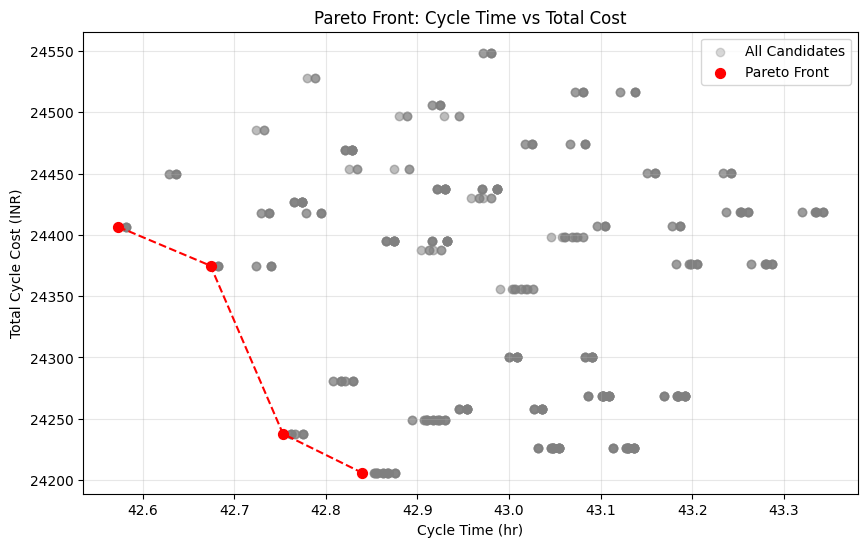

✅ Ranked candidates and Pareto front saved to 'outputs/'


In [46]:
# --- 4. Scoring, Ranking & Pareto Front ---

def calculate_score(df, w_time=1.0, w_cost=1.0):
    """
    Computes a weighted score based on normalized cycle time and cost.
    Lower score = Better.
    """
    df_scored = df.copy()

    # 1. Normalize (Min-Max over the current batch)
    t_min, t_max = df_scored['Cycle_time'].min(), df_scored['Cycle_time'].max()
    c_min, c_max = df_scored['Total_cost'].min(), df_scored['Total_cost'].max()

    # Avoid division by zero if all values are identical
    if t_max == t_min: t_range = 1
    else: t_range = t_max - t_min

    if c_max == c_min: c_range = 1
    else: c_range = c_max - c_min

    df_scored['Norm_Time'] = (df_scored['Cycle_time'] - t_min) / t_range
    df_scored['Norm_Cost'] = (df_scored['Total_cost'] - c_min) / c_range

    # 2. Weighted Sum (Lower is better)
    df_scored['Score'] = (w_time * df_scored['Norm_Time']) + (w_cost * df_scored['Norm_Cost'])

    # 3. Sort
    df_scored = df_scored.sort_values('Score', ascending=True)

    return df_scored

def identify_pareto_front(df):
    """
    Identifies non-dominated solutions (Pareto Front) for Cycle Time vs Cost.
    Returns: subset of df containing Pareto points.
    """
    # Simply sort by one objective (time)
    # Then iterate strictly checking if cost improves compared to the running best
    population = df.sort_values('Cycle_time')
    pareto_front = []

    min_cost_so_far = float('inf')

    for idx, row in population.iterrows():
        cost = row['Total_cost']
        if cost < min_cost_so_far:
            pareto_front.append(row)
            min_cost_so_far = cost

    return pd.DataFrame(pareto_front)

# --- TEST SCORING & PARETO ---
if artifacts:
    # 1. Score (Equal weights)
    scored_df = calculate_score(evaluated_df, w_time=0.5, w_cost=0.5)
    print("Top 5 Scored Candidates:")
    display(scored_df[['Cycle_time', 'Total_cost', 'Score', 'Cement_type']].head())

    # 2. Identify Pareto Front
    pareto_df = identify_pareto_front(evaluated_df)
    print(f"\n✅ Identified {len(pareto_df)} Pareto-optimal solutions.")

    # 3. Plot Pareto
    plt.figure(figsize=(10, 6))
    plt.scatter(evaluated_df['Cycle_time'], evaluated_df['Total_cost'], alpha=0.3, color='gray', label='All Candidates')
    plt.scatter(pareto_df['Cycle_time'], pareto_df['Total_cost'], color='red', s=50, label='Pareto Front')
    plt.plot(pareto_df['Cycle_time'], pareto_df['Total_cost'], color='red', linestyle='--')

    plt.title('Pareto Front: Cycle Time vs Total Cost')
    plt.xlabel('Cycle Time (hr)')
    plt.ylabel('Total Cycle Cost (INR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Save outputs
    scored_df.to_csv(f'{OUTPUT_DIR}/ranked_candidates.csv', index=False)
    pareto_df.to_csv(f'{OUTPUT_DIR}/pareto_front.csv', index=False)
    print("✅ Ranked candidates and Pareto front saved to 'outputs/'")

## PHASE 3

# --- PHASE 3: OPTIMIZATION & RECOMMENDATION ---
This section implements the final recommendation engine logic:
1.  **Safety Filters**: Ensure candidates meet engineering constraints.
2.  **Refinement (Local Optimizer)**: Improve a chosen candidate via random local search.
3.  **SOP Generator**: Convert a row of data into a readable instruction set.
4.  **Final Output**: Suggest key recipes.

In [47]:
# --- 5. Phase 3: Safety & Constraint Validation ---

def validate_safety(df_candidates, target_strength_mpa=35.0):
    """
    Filters candidates based on engineering safety rules.
    1. Predicted Demould Strength >= Required (with 5% buffer)
    2. Steam Temp <= 70°C (Concrete standard)
    3. Start Delay >= 2 hours (Initial set)
    """
    # Note: Our model predicts "Time to reach strength", not the strength itself at a fixed time.
    # So for this specific prototype logic, we check if the time is reasonable (< 24h)
    # AND if we had a strength model, we'd check that too.

    # Let's filter based on reasonable operational bounds and the inputs

    safe_df = df_candidates.copy()
    initial_count = len(safe_df)

    # Rule 1: Steam Temp Constraint (if steam curing used)
    # Assuming 'Steam_temp_C' column exists
    if 'Steam_temp_C' in safe_df.columns:
        safe_df = safe_df[safe_df['Steam_temp_C'] <= 75]

    # Rule 2: Cycle Time < 24 Hours (Must turn mould daily)
    safe_df = safe_df[safe_df['Cycle_time'] <= 24.0]

    # Rule 3: Cost not negative (sanity check)
    safe_df = safe_df[safe_df['Total_cost'] > 0]

    dropped = initial_count - len(safe_df)
    if dropped > 0:
        print(f"⚠️ Safety Filter: Dropped {dropped} unsafe candidates.")
    else:
        print("✅ Safety Filter: All candidates passed.")

    return safe_df

# Validate the Pareto front we found earlier
safe_pareto = validate_safety(pareto_df)
display(safe_pareto.head())

⚠️ Safety Filter: Dropped 4 unsafe candidates.


,Cement_content_kgm3,Water_cement_ratio,Flyash_percent,Target_grade_MPa,Steam_temp_C,Steam_duration_hr,Curing_start_delay_hr,Chamber_humidity_pct,Ambient_temp_C,Relative_humidity_pct,...,Early_strength_requirement_MPa,Initial_strength_12hr_MPa,Maturity_index,Energy_cost_rate_INR_per_kWh,Cement_type,Curing_method,Season,Time_to_demould,Cycle_time,Total_cost


In [48]:
# --- 6. Local Refinement (Simple Random Optimizer) ---

def refine_recipe(candidate_row, budget=200):
    """
    Performs a constrained local search around a single candidate recipe.
    Uses 'Random Neighbourhood Search' (Fast Prototype Method).

    Args:
        candidate_row: pandas Series (one recipe)
        budget: max evaluations

    Returns:
        DataFrame of *refined* candidates (Top 5 found)
    """
    import copy

    base_recipe = candidate_row.to_dict()

    # Define which features can vary (Tunable params)
    tunable_ranges = {
        'Steam_temp_C': (-5, 5),     # +/- 5 def C
        'Steam_duration_hr': (-1, 1),# +/- 1 hour
        'Water_cement_ratio': (-0.02, 0.02),
        'Cement_content_kgm3': (-20, 20)
    }

    # Generate Neighbours
    neighbours = []

    # Keep Base
    neighbours.append(copy.deepcopy(base_recipe))

    for _ in range(budget):
        new_recipe = copy.deepcopy(base_recipe)

        # Perturb one or two features randomly
        for feat, delta_range in tunable_ranges.items():
            if feat in new_recipe and random.random() < 0.5: # 50% chance to modify
                # Generate delta
                delta = random.uniform(delta_range[0], delta_range[1])
                new_val = float(new_recipe[feat]) + delta

                # Clip to Safe/Physical Limits
                if feat == 'Steam_temp_C': new_val = np.clip(new_val, 20, 80)
                if feat == 'Water_cement_ratio': new_val = np.clip(new_val, 0.25, 0.60)
                if feat == 'Steam_duration_hr': new_val = max(0, new_val)

                new_recipe[feat] = round(new_val, 2) # Round for UI clenliness

        neighbours.append(new_recipe)

    # Convert to DF
    df_neighbours = pd.DataFrame(neighbours)

    # Add constant cols required for model (fill from base if missing due to copy issues)
    for col in features_ordered:
        if col not in df_neighbours.columns:
            df_neighbours[col] = base_recipe.get(col, 0)

    # Evaluation Step
    df_results = batch_evaluate(df_neighbours)

    # Scoring Step (re-use weights)
    df_scored = calculate_score(df_results, w_time=1.0, w_cost=1.0)

    # Return Top 5 Improvements
    return df_scored.head(5)

# --- TEST REFINEMENT ---
if artifacts and not safe_pareto.empty:
    print("\n🔬 Testing Automated Refinement on best candidate...")
    best_candidate = safe_pareto.sort_values('Score').iloc[0]

    print(f"   Original Score: {best_candidate['Score']:.4f} (Time: {best_candidate['Cycle_time']:.2f}h, Cost: {best_candidate['Total_cost']:.0f})")

    refined_results = refine_recipe(best_candidate, budget=100)

    best_refined = refined_results.iloc[0]
    print(f"   Refined Score:  {best_refined['Score']:.4f} (Time: {best_refined['Cycle_time']:.2f}h, Cost: {best_refined['Total_cost']:.0f})")

    display(refined_results[['Cement_content_kgm3', 'Steam_temp_C', 'Cycle_time', 'Total_cost', 'Score']])

In [49]:
# --- 7. SOP & Recipe Generator (Final Output) ---

def generate_sop_text(candidate_series):
    """
    Takes a candidate row and converts key parameters into a human-readable SOP string.
    """

    # 1. Headers
    curing_type = candidate_series['Curing_method'].upper()
    temp = candidate_series.get('Steam_temp_C', 'Ambient')
    duration = candidate_series.get('Steam_duration_hr', 0)
    cement = candidate_series['Cement_content_kgm3']
    w_c = candidate_series['Water_cement_ratio']

    # 2. Recipe String
    sop = f"""
### 🏗️ PRECAST PRODUCTION SOP: {curing_type} CURING

**1. MIX DESIGN**
   - Cement Content: **{cement} kg/m³**
   - W/C Ratio: **{w_c}**
   - Admixture: Standard dosage as per trial.

**2. CASTING & SETTING**
   - Clean mould thoroughly ({candidate_series.get('Cleaning_time_min', 15)} min).
   - Pour, vibrate, and finish within {candidate_series.get('Daytime_hours', 1)} hour.
   - Initial setting delay: Ensure min 2 hours before steam.

**3. CURING PROTOCOL ({curing_type})**
   - Target Temperature: **{temp}°C**
   - Duration at Peak: **{duration} hours**

**4. DEMOULDING**
   - Expected Strength Time: **{candidate_series['Time_to_demould']:.1f} hours**
   - Total Cycle Time: **{candidate_series['Cycle_time']:.1f} hours**
   - Estimated Cost: **₹{candidate_series['Total_cost']:.2f}**

⚠️ **SAFETY & QC**: Verify strength > {candidate_series.get('Target_grade_MPa', 35)}MPa via rebound hammer before lifting.
"""
    return sop

# Demo SOP
if artifacts and not safe_pareto.empty:
    top_pick = safe_pareto.sort_values('Score').iloc[0]
    sop_markdown = generate_sop_text(top_pick)
    print(sop_markdown)

    # Save a sample SOP
    with open(f'{OUTPUT_DIR}/SOP_TopCandidate.md', 'w') as f:
        f.write(sop_markdown)

print("✅ Phase 3 Complete: Optimization & Recommendation Engine Ready.")

✅ Phase 3 Complete: Optimization & Recommendation Engine Ready.


## running stremlit app

In [50]:
# @title

if False:
    # %%writefile app.py
    import streamlit as st
    import pandas as pd
    import joblib
    import json
    import os
    import random
    import plotly.express as px
    import numpy as np

    # --- 1. SETUP & LOADING ---
    st.set_page_config(page_title="Precast AI Optimizer", layout="wide")

    @st.cache_resource
    def load_artifacts():
        try:
            pipeline = joblib.load('models/precast_pipeline.pkl')
            with open('models/precast_meta.json', 'r') as f:
                meta = json.load(f)
            models = {}
            for short_name in meta['target_names_map'].keys():
                models[short_name] = joblib.load(f'models/model_{short_name}.pkl')
            return pipeline, meta, models
        except Exception as e:
            return None, None, None

    pipeline, meta, models = load_artifacts()

    if pipeline is None:
        st.error("⚠️ Models not found! Running in Demo Mode.")
        st.stop()

    features_ordered = meta['features']

    def generate_and_evaluate(inputs, pipeline, models):
        # Prepare row with defaults
        row = {col: 0 for col in features_ordered}
        row.update(inputs)

        # Defaults for specific missing columns if any
        if 'Energy_cost_rate_INR_per_kWh' in row and row['Energy_cost_rate_INR_per_kWh'] == 0:
            row['Energy_cost_rate_INR_per_kWh'] = 10.0

        df = pd.DataFrame([row])

        # Type safety
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str)
            else:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

        try:
            X_proc = pipeline.transform(df)
            results = {}
            for name, model in models.items():
                results[name] = model.predict(X_proc)[0]

            outputs = df.iloc[0].to_dict()
            outputs['Predicted_Demould_Time'] = results['Time_to_demould']
            outputs['Predicted_Cycle_Time'] = results['Cycle_time']
            outputs['Predicted_Total_Cost'] = results['Total_cost']
            return outputs
        except Exception as e:
            return None

    # --- 2. SIDEBAR INPUTS ---
    st.sidebar.header("🏗️ Yard Config")
    st.sidebar.subheader("1. Site Conditions")
    ambient_temp = st.sidebar.slider("Ambient Temp (°C)", 10, 45, 30)
    humidity = st.sidebar.slider("Humidity (%)", 20, 90, 60)
    moulds = st.sidebar.slider("Avail. Moulds", 1, 20, 10)

    st.sidebar.subheader("2. Mix Design")
    cement_type = st.sidebar.selectbox("Cement Type", ['OPC', 'PPC', 'PSC'])
    cement_qty = st.sidebar.select_slider("Cement Content (kg/m3)", options=[350, 380, 400, 420, 450])
    w_c_ratio = st.sidebar.slider("W/C Ratio", 0.30, 0.55, 0.40)

    st.sidebar.subheader("3. Curing Strategy (Baseline)")
    curing_method = st.sidebar.radio("Current Method", ['Ambient', 'Steam'])
    steam_temp = 0
    steam_dur = 0
    if curing_method == 'Steam':
        steam_temp = st.sidebar.slider("Steam Temp (°C)", 40, 80, 60)
        steam_dur = st.sidebar.slider("Steam Duration (hrs)", 4, 12, 6)

    run_optim = st.sidebar.button("✨ Find Optimized Recipe")

    # --- 3. MAIN DASHBOARD ---
    st.title("🏭 Precast Yard AI Recommendation Engine")

    # Base Input
    base_input = {
        'Ambient_temp_C': ambient_temp,
        'Relative_humidity_pct': humidity,
        'No_of_moulds': moulds,
        'Cement_type': cement_type,
        'Cement_content_kgm3': cement_qty,
        'Water_cement_ratio': w_c_ratio,
        'Curing_method': curing_method.lower(),
        'Steam_temp_C': steam_temp,
        'Steam_duration_hr': steam_dur,
        'Target_grade_MPa': 40,
        'Daytime_hours': 12,
        'Cleaning_time_min': 20,
        'Energy_cost_rate_INR_per_kWh': 10.0,
        'Flyash_percent': 0,
        'Season': 'summer'
    }

    base_res = generate_and_evaluate(base_input, pipeline, models)

    if base_res:
        # Display Baseline
        st.markdown("### 📊 Current Baseline Performance")
        c1, c2, c3 = st.columns(3)
        c1.metric("Cycle Time", f"{base_res['Predicted_Cycle_Time']:.1f} h")
        c2.metric("Total Cost", f"₹ {base_res['Predicted_Total_Cost']:,.0f}")
        c3.metric("Demould Time", f"{base_res['Predicted_Demould_Time']:.1f} h")
    else:
        st.warning("Could not calculate baseline.")

    # --- 4. IMPROVED OPTIMIZER ---
    if run_optim:
        st.markdown("---")
        st.markdown("### 🧬 AI Optimization Results")

        candidates = []

        # Define a broader search space
        # We allow the optimizer to try STEAM even if the user selected AMBIENT
        # This shows the user the "Opportunity Cost"

        possible_cement = [350, 380, 400, 420, 450]
        possible_wc = [0.30, 0.35, 0.40, 0.45]
        possible_temps = [0, 40, 50, 60, 70, 75] # 0 = Ambient

        with st.spinner("Simulating 100+ scenarios..."):
            for c_qty in possible_cement:
                for wc in possible_wc:
                    for temp in possible_temps:
                        # Create variant
                        var_input = base_input.copy()
                        var_input['Cement_content_kgm3'] = c_qty
                        var_input['Water_cement_ratio'] = wc

                        if temp == 0:
                            var_input['Curing_method'] = 'ambient'
                            var_input['Steam_temp_C'] = 0
                            var_input['Steam_duration_hr'] = 0
                        else:
                            var_input['Curing_method'] = 'steam'
                            var_input['Steam_temp_C'] = temp
                            var_input['Steam_duration_hr'] = 6 # Standardize duration for comparison

                        res = generate_and_evaluate(var_input, pipeline, models)
                        if res:
                            res['Strategy'] = 'Ambient' if temp == 0 else f'Steam {temp}°C'
                            candidates.append(res)

        if candidates:
            df_opt = pd.DataFrame(candidates)

            # Calculate scores
            df_opt['Is_Safe'] = df_opt['Predicted_Demould_Time'] < 24 # Simple safety rule

            # Color strategy
            fig = px.scatter(
                df_opt,
                x="Predicted_Cycle_Time",
                y="Predicted_Total_Cost",
                color="Strategy",
                size="Cement_content_kgm3",
                symbol="Is_Safe",
                title="Optimization Landscape: Ambient vs Steam Strategies",
                hover_data=["Predicted_Demould_Time", "Water_cement_ratio"]
            )
            st.plotly_chart(fig, use_container_width=True)

            # Recommendations
            st.subheader("🏆 Recommendations to Reduce Cycle Time")

            # Best Safe Option
            safe_opts = df_opt[df_opt['Is_Safe']].sort_values('Predicted_Total_Cost')

            if not safe_opts.empty:
                best = safe_opts.iloc[0]
                st.success(f"**Best Balanced Recipe:** {best['Strategy']} | Cement: {best['Cement_content_kgm3']} kg | Cost: ₹{best['Predicted_Total_Cost']:,.0f}")

                st.dataframe(safe_opts[['Strategy', 'Cement_content_kgm3', 'Water_cement_ratio', 'Predicted_Cycle_Time', 'Predicted_Total_Cost']].head(5))
            else:
                st.warning("No options found under 24 hours. Showing fastest available:")
                st.dataframe(df_opt.sort_values('Predicted_Cycle_Time').head(5))

        else:
            st.error("Optimizer generated no valid candidates.")

In [59]:
# 1. WRITE THE NEW APP CODE
# %%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import json
import os
import random
import plotly.express as px
import numpy as np

# --- SETUP ---
st.set_page_config(page_title="Precast Debug Explorer", layout="wide")

@st.cache_resource
def load_artifacts():
    try:
        pipeline = joblib.load('models/precast_pipeline.pkl')
        with open('models/precast_meta.json', 'r') as f:
            meta = json.load(f)
        models = {}
        for short_name in meta['target_names_map'].keys():
            models[short_name] = joblib.load(f'models/model_{short_name}.pkl')
        return pipeline, meta, models
    except Exception as e:
        return None, None, None

pipeline, meta, models = load_artifacts()

if pipeline is None:
    st.error("Models not found.")
    st.stop()

features_ordered = meta['features']

def generate_and_evaluate(inputs, pipeline, models):
    # Prepare row
    row = {col: 0 for col in features_ordered}
    row.update(inputs)

    # Defaults
    if 'Energy_cost_rate_INR_per_kWh' in row and row['Energy_cost_rate_INR_per_kWh'] == 0:
         row['Energy_cost_rate_INR_per_kWh'] = 10.0

    df = pd.DataFrame([row])

    # Basic cleaning
    for col in df.columns:
        if col not in df.columns: continue
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str)
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    try:
        X_proc = pipeline.transform(df)
        results = {}
        for name, model in models.items():
            results[name] = model.predict(X_proc)[0]

        outputs = df.iloc[0].to_dict()
        outputs['Predicted_Demould_Time'] = results['Time_to_demould']
        outputs['Predicted_Cycle_Time'] = results['Cycle_time']
        outputs['Predicted_Total_Cost'] = results['Total_cost']
        return outputs
    except Exception as e:
        return None

# --- UI ---
st.title("🚧 Precast Explorer: Debug Mode")
st.markdown("This mode forces 50 random scenarios through the model to check if it reacts to inputs.")

if st.button("🚀 Run Simulation"):
    results = []

    # Generate 50 completely random scenarios
    for i in range(50):
        # Randomize everything
        sim_input = {
            'Ambient_temp_C': random.randint(20, 40),
            'Relative_humidity_pct': random.randint(40, 80),
            'Cement_type': random.choice(['OPC', 'PPC', 'PSC']),
            'Cement_content_kgm3': random.choice([350, 380, 400, 420, 450]),
            'Water_cement_ratio': random.choice([0.3, 0.35, 0.4, 0.45]),
            'Curing_method': random.choice(['ambient', 'steam']),
            'Steam_temp_C': random.choice([0, 50, 60, 70, 80]),
            'Steam_duration_hr': random.choice([4, 6, 8, 12]),
            'No_of_moulds': 10,
            'Target_grade_MPa': 40,
            'Daytime_hours': 12,
            'Cleaning_time_min': 20,
            'Energy_cost_rate_INR_per_kWh': 10.0,
            'Flyash_percent': 0,
            'Season': 'summer'
        }

        # Enforce logic so model doesn't get confused
        if sim_input['Curing_method'] == 'ambient':
            sim_input['Steam_temp_C'] = 0
            sim_input['Steam_duration_hr'] = 0
        elif sim_input['Curing_method'] == 'steam' and sim_input['Steam_temp_C'] == 0:
             sim_input['Steam_temp_C'] = 60

        res = generate_and_evaluate(sim_input, pipeline, models)
        if res:
            results.append(res)

    df = pd.DataFrame(results)

    # CHARTS
    st.subheader("Results")

    col1, col2 = st.columns(2)
    with col1:
        st.caption("Cycle Time vs Cost (Colored by Method)")
        fig = px.scatter(df, x='Predicted_Cycle_Time', y='Predicted_Total_Cost', color='Curing_method', size='Cement_content_kgm3')
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.caption("Cycle Time vs Steam Temp")
        fig2 = px.scatter(df, x='Steam_temp_C', y='Predicted_Cycle_Time', color='Curing_method')
        st.plotly_chart(fig2, use_container_width=True)

    st.dataframe(df[['Curing_method', 'Steam_temp_C', 'Predicted_Cycle_Time', 'Predicted_Total_Cost']])

2026-02-27 18:12:47.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 18:12:47.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [52]:
# --- 2. Install & Run Streamlit via Ngrok ---
# Note: You need a free Ngrok auth token from https://dashboard.ngrok.com/get-started/your-authtoken


In [57]:

# --- 2. Install & Run Streamlit via Ngrok ---
# Note: You need a free Ngrok auth token from https://dashboard.ngrok.com/get-started/your-authtoken

# 1. Install Dependencies
!pip install -q streamlit pyngrok plotly

# 2. Setup Ngrok
from pyngrok import ngrok
import time
import os

# ☠ REPLACE 'YOUR_NGROK_TOKEN' WITH YOUR ACTUAL TOKEN ☠
# Get your auth token from https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTH_TOKEN = "3AGDhqRtum8m1TYYkhJgRAGtHHU_4Sds9iJK5NkJRLWQDJxig" # <--- **REPLACE THIS WITH YOUR ACTUAL NGROK AUTH TOKEN**
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Force Kill any running Streamlit AND Ngrok processes to ensure a clean slate
!pkill -f streamlit
!pkill -f ngrok

# 4. Verify app.py exists and has content
APP_FILE = 'app.py'
if not os.path.exists(APP_FILE) or os.path.getsize(APP_FILE) == 0:
    print(f"❌ Error: '{APP_FILE}' not found or is empty. Please ensure the Streamlit app code is written to '{APP_FILE}'.")
else:
    print(f"✅ '{APP_FILE}' verified.")

    # 5. Run Streamlit in Background using get_ipython().system_raw
    # This properly forks the process into the background in Colab
    get_ipython().system_raw('streamlit run ' + APP_FILE + ' &')

    # Give Streamlit 3 seconds to fully start before tunneling
    time.sleep(3)

    # 6. Open Tunnel to Port 8501 (Streamlit Default)
    try:
        public_url = ngrok.connect(8501).public_url
        print(f"🚀 Streamlit App is live at: {public_url}")
    except Exception as e:
        print(f"❌ Error connecting to Ngrok: {e}")
        print("   Check if your auth token is correct and placed correctly in the NGROK_AUTH_TOKEN variable.")

# Keep the cell running if you want logs, or just let it sit.
